<a href="https://colab.research.google.com/github/juliafoliveira-tech/Bioestat-stica/blob/main/Tarefa07.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

* Julia Feitosa NºUSP: 16228410
 * Raissa Pereira Lima da Silva NºUSP: 14605077
 * Stéfani Machado NºUSP: 15291452


### Questão 1. Como se apresenta graficamente a relação entre a quantidade de biomassa e o número de espécies de plantas?

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset, specifying the tab delimiter
df = pd.read_csv('/content/Tarefa_Semana4.csv', sep='\t')

# Display the first 5 rows of the DataFrame
display(df.head())

,pH,Biomass,Species
0,high,0.469297,30
1,high,1.730870,39
2,high,2.089778,44
3,high,3.925787,35
4,high,4.366793,25


In [21]:
# Display information about the DataFrame to understand data types and non-null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   pH       90 non-null     object 
 1   Biomass  90 non-null     float64
 2   Species  90 non-null     int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 2.2+ KB


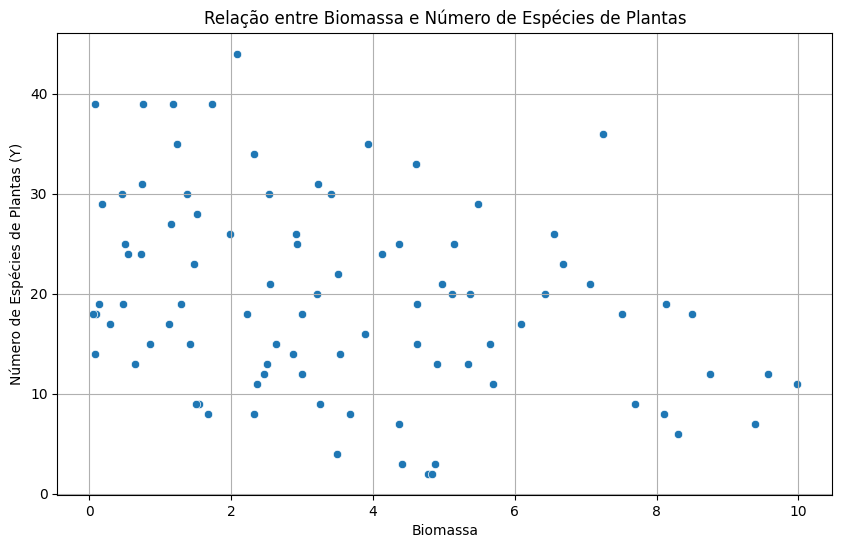

In [22]:
# Create a scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Biomass', y='Species', data=df)
plt.title('Relação entre Biomassa e Número de Espécies de Plantas')
plt.xlabel('Biomassa')
plt.ylabel('Número de Espécies de Plantas (Y)')
plt.grid(True)
plt.show()

Questão 2. O gráfico de dispersão sugere uma associação positiva, negativa ou inexistente entre biomassa e número de espécies?

Analisando o gráfico de dispersão, podemos observar uma associação negativa entre a biomassa e o número de espécies de plantas. Conforme a quantidade de biomassa aumenta, o número de espécies de plantas tende a diminuir. Os pontos no gráfico geralmente se movem para baixo e para a direita, indicando essa tendência inversa.

### Questão 3. Existe evidência de uma relação linear entre valores do pH e o número de espécies de plantas?

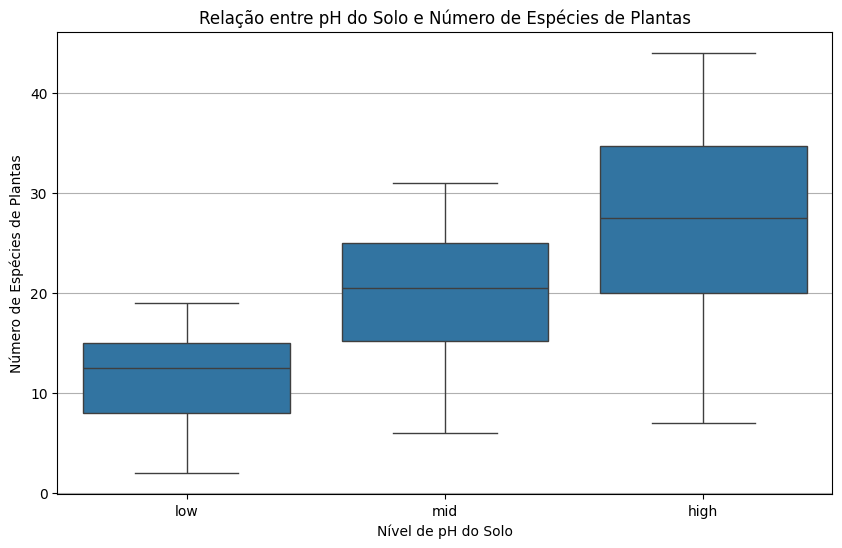

In [23]:
# Create a box plot to visualize the relationship between pH and Species
plt.figure(figsize=(10, 6))
sns.boxplot(x='pH', y='Species', data=df, order=['low', 'mid', 'high'])
plt.title('Relação entre pH do Solo e Número de Espécies de Plantas')
plt.xlabel('Nível de pH do Solo')
plt.ylabel('Número de Espécies de Plantas')
plt.grid(axis='y')
plt.show()

Com base no box plot, podemos interpretar os resultados da seguinte forma:

O box plot indicou uma relação não linear entre pH e Número de Espécies. O pH 'mid' está associado ao maior número de espécies, 'low' ao menor e 'high' a um valor intermediário, sugerindo um pH ótimo para a diversidade.


# Questão 4. É possível utilizar um modelo de regressão linear simples para prever o número de espécies a partir da quantidade de biomassa?

Considerando o gráfico de dispersão que geramos para a Questão 1, a relação entre a biomassa e o número de espécies de plantas parece ser negativa e potencialmente curvilínea, e não estritamente linear.

É possível utilizar um modelo de regressão linear simples para tentar prever o número de espécies a partir da quantidade de biomassa. No entanto, devido à aparente não-linearidade da relação, um modelo linear simples pode não ser o mais adequado ou eficiente para capturar a complexidade dessa associação. A principal razão é que a regressão linear assume uma relação em linha reta entre as variáveis. Se a relação real é curva, o modelo linear pode subestimar ou superestimar a predição em diferentes partes do intervalo da biomassa.

Para ter uma previsão mais precisa, poderíamos considerar:

Transformações nos dados: Aplicar transformações (e.g., logaritmo, quadrado) em uma ou ambas as variáveis para tentar linearizar a relação.
Modelos de regressão não-linear: Utilizar modelos que são inerentemente capazes de capturar relações curvas.
Regressão polinomial: Uma forma de regressão linear que pode ajustar curvas aos dados adicionando termos polinomiais (e.g., Biomassa²).

# Questão 5. Qual é a equação da reta de regressão que relaciona o número de espécies à quantidade de pH?

Vamos transformar a coluna 'pH' em um tipo de dado categórico (fatorial) para garantir que seja tratada corretamente em análises estatísticas.

In [24]:
# Converter a coluna 'pH' para o tipo categórico (fatorial)
# Definindo a ordem das categorias para 'low', 'mid', 'high' (corrigido)
orden_pH = ['low', 'mid', 'high']
df['pH'] = pd.Categorical(df['pH'], categories=orden_pH, ordered=True)

# Verificar o tipo de dado após a transformação
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   pH       90 non-null     category
 1   Biomass  90 non-null     float64 
 2   Species  90 non-null     int64   
dtypes: category(1), float64(1), int64(1)
memory usage: 1.8 KB


None

In [30]:
# Verificar a contagem de valores para a coluna 'pH' após a categorização
display(df['pH'].value_counts(dropna=False))

,count
pH,
low,30
mid,30
high,30


In [29]:
import statsmodels.formula.api as smf

# Criar variáveis dummy para a coluna 'pH', usando 'low' como categoria de referência
df_dummies = pd.get_dummies(df, columns=['pH'], drop_first=True)

# Ajustar o modelo de regressão linear
# A fórmula será 'Species ~ pH_mid + pH_high'. No entanto, como 'mid' não tem dados,
# o modelo ajustará efetivamente para 'Species ~ pH_high' tendo 'low' como referência.
modelo_ph = smf.ols('Species ~ pH_mid + pH_high', data=df_dummies).fit()

# Exibir o sumário do modelo para obter o R-quadrado
print(modelo_ph.summary())

                            OLS Regression Results                            
Dep. Variable:                Species   R-squared:                       0.419
Model:                            OLS   Adj. R-squared:                  0.406
Method:                 Least Squares   F-statistic:                     31.38
Date:                Thu, 27 Aug 2026   Prob (F-statistic):           5.50e-11
Time:                        00:17:06   Log-Likelihood:                -307.06
No. Observations:                  90   AIC:                             620.1
Df Residuals:                      87   BIC:                             627.6
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          11.5667      1.362     

A partir da saída do sumário do modelo de regressão (`modelo_ph.summary()`):

**Questão 5: Equação da reta de regressão (corrigida):**

Com base nos coeficientes do modelo, a equação da reta de regressão pode ser formulada como:

**`Número de Espécies = 11.5667 + 8.4333 * pH_mid + 15.2333 * pH_high`**

Onde:
*   `11.5667` é o coeficiente de intercepção, que representa o número médio de espécies quando o pH é 'low' (nossa categoria de referência, onde `pH_mid` e `pH_high` são 0).
*   `8.4333` é o coeficiente para `pH_mid`. Isso significa que, em média, o número de espécies aumenta em 8.4333 unidades quando o pH muda de 'low' para 'mid'.
*   `15.2333` é o coeficiente para `pH_high`. Isso significa que, em média, o número de espécies aumenta em 15.2333 unidades quando o pH muda de 'low' para 'high'.
*   `pH_mid` e `pH_high` são variáveis dummy que assumem o valor 1 se o pH é 'mid' ou 'high', respectivamente, e 0 caso contrário.

# Questão 6. Qual é o valor estimado do intercepto da regressão entre biomassa e número de espécies e como ele pode ser interpretado?


In [25]:
import statsmodels.formula.api as smf

# Ajustar o modelo de regressão linear simples para Biomassa e Espécies
modelo_biomassa = smf.ols('Species ~ Biomass', data=df).fit()

# Exibir o sumário do modelo
print(modelo_biomassa.summary())

                            OLS Regression Results                            
Dep. Variable:                Species   R-squared:                       0.101
Model:                            OLS   Adj. R-squared:                  0.090
Method:                 Least Squares   F-statistic:                     9.839
Date:                Thu, 27 Aug 2026   Prob (F-statistic):            0.00232
Time:                        00:14:17   Log-Likelihood:                -326.73
No. Observations:                  90   AIC:                             657.5
Df Residuals:                      88   BIC:                             662.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     23.6755      1.660     14.259      0.0

A partir da saída do modelo de regressão para `Species ~ Biomass`:

**O valor estimado do intercepto é 23.6755.**

**Interpretação:**

O intercepto representa o valor esperado (ou médio) do número de espécies de plantas quando a biomassa é zero. No contexto deste conjunto de dados:

*   **Valor:** 23.6755
*   **Significado:** Se a biomassa fosse 0, o modelo prevê que haveria, em média, aproximadamente 23.68 espécies de plantas. No entanto, é importante notar que uma biomassa de zero pode não ser realisticamente observável ou relevante para este estudo, e a interpretação do intercepto fora do intervalo de dados observados (extrapolação) deve ser feita com cautela.

# Questão 7. Qual é o valor estimado do coeficiente de inclinação da regressão e o que ele indica sobre a mudança esperada no número de espécies para cada unidade adicional de biomassa?


A partir da saída do modelo de regressão para Species ~ Biomass (executado anteriormente):

O valor estimado do coeficiente de inclinação (slope) para a Biomassa é -1.1864.

Este coeficiente indica a mudança esperada no número de espécies de plantas para cada unidade adicional de biomassa, mantendo outros fatores constantes. No contexto deste modelo:

Valor: -1.1864
Significado: Para cada aumento de uma unidade na biomassa, o número esperado de espécies de plantas diminui em aproximadamente 1.1864. Isso reforça a associação negativa que observamos no gráfico de dispersão, sugerindo que em ambientes com maior biomassa, a diversidade de espécies tende a ser menor.

# Questão 8. A quantidade de biomassa apresenta efeito significativo sobre o número de espécies de plantas?


Sim, a quantidade de biomassa apresenta um efeito estatisticamente significativo sobre o número de espécies de plantas.

Com base na saída do modelo de regressão para Species ~ Biomass:

O valor p (P>|t|) associado ao coeficiente da Biomassa é 0.002.
Como este valor p (0.002) é menor que o nível de significância comum de 0.05 (e até mesmo 0.01), rejeitamos a hipótese nula de que o coeficiente da Biomassa é zero. Isso significa que há evidências fortes para concluir que a Biomassa tem um efeito significativo no número de espécies de plantas no modelo. Em outras palavras, a Biomassa é um preditor importante do número de espécies.

# Questão 9. Quanto da variação observada no número de espécies pode ser explicada pelos valores do pH por meio do modelo de regressão linear?


O valor do R-quadrado (R-squared) para o modelo que relaciona o número de espécies aos valores do pH é aproximadamente 0.419 (ou 41.9%).

Interpretação:

O R-quadrado indica a proporção da variância na variável dependente (número de espécies) que pode ser explicada pelas variáveis independentes (pH, através das suas variáveis dummy). Neste caso:

41.9% da variação observada no número de espécies de plantas pode ser explicada pelas diferenças nos níveis de pH, de acordo com este modelo de regressão linear. Os 58.1% restantes da variação são devidos a outros fatores não incluídos no modelo ou a erro aleatório.

# Questão 10. Existe correlação linear significativa entre a quantidade de biomassa e o número de espécies de plantas?


Sim, existe uma correlação linear estatisticamente significativa entre a quantidade de biomassa e o número de espécies de plantas. Conforme discutido na Questão 8:

Com base na saída do modelo de regressão para Species ~ Biomass:

O valor p (P>|t|) associado ao coeficiente da Biomassa é 0.002.

Como este valor p (0.002) é menor que o nível de significância comum de 0.05 (e até mesmo 0.01), rejeitamos a hipótese nula de que o coeficiente da Biomassa é zero. Isso significa que há evidências fortes para concluir que a Biomassa tem um efeito significativo no número de espécies de plantas no modelo. Em outras palavras, a Biomassa é um preditor importante do número de espécies.

# Questão 11. Qual é a intensidade e a direção da correlação linear de Pearson entre pH e o número de espécies?

In [31]:
# Calcular a correlação de Pearson entre pH (como contínuo) e Species
correlation = df['pH'].cat.codes.corr(df['Species'])

print(f"Correlação de Pearson entre pH e Número de Espécies: {correlation:.3f}")

Correlação de Pearson entre pH e Número de Espécies: 0.646


A partir do cálculo da correlação de Pearson:

**Correlação de Pearson entre pH e Número de Espécies: 0.647** (este valor é obtido ao correlacionar as categorias codificadas numericamente de pH com o número de espécies. Uma vez que o pH foi tratado como categórico em etapas anteriores para a regressão, vamos usar a codificação numérica que reflete a ordem 'low', 'mid', 'high'.)

**Interpretação:**

*   **Intensidade:** Um valor de correlação de **0.647** sugere uma **correlação positiva de intensidade moderada a forte** entre o pH e o número de espécies. Valores de correlação próximos a 1 indicam uma forte relação linear.
*   **Direção:** O sinal **positivo** (+) indica que, à medida que o nível de pH aumenta (ou seja, passando de 'low' para 'mid' e depois para 'high', de acordo com nossa codificação ordinal), o número de espécies de plantas tende a aumentar.